# Radio-heating emulators: `rh` and `norh`

These two emulators were trained on 21cmFAST simulations with an excess radio background sourced by mini-halo galaxies and dark matter–baryon scattering (scattering dark matter, SDM), **with** (`rh`) and **without** (`norh`) radio (soft-photon) heating of the gas. Everything else in the simulations is the same.

They take six parameters, all in $\log_{10}$: `fR_mini`, `F_STAR7_MINI`, `L_X_MINI`, `F_ESC7_MINI`, `m_chi` [GeV] and `sigma_SDM` [cm$^2$]. They return the global neutral fraction $\overline{x}_{\rm HI}$, brightness temperature $\delta\overline{T}_b$ [mK] and excess radio temperature $\overline{T}_{\rm R}$ [K] at 110 redshifts ($4.9 < z < 49$), and the Thomson optical depth $\tau_e$.

In this tutorial we take some parameter sets from one of the simulation databases, evaluate the emulator on them and compare with the simulations.

**Weights.** The trained weights are not part of the repository. Put the file you received (`rh_weights.pt` or `norh_weights.pt`) in `py21cmemu/models/radio_heating/` or in `<data-path>/radio_heating/` (py21cmEMU data directory, by default `~/.local/share/py21cmEMU`), or pass its location with `Emulator(emulator="rh", weights_path=...)`.

In [1]:
import h5py
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.lines import Line2D

from py21cmemu import Emulator, RHEmulatorInput

## Settings

In [2]:
EMULATOR = "rh"  # "rh" (with radio heating) or "norh" (without)

# 21cmFAST summary databases (not part of the repository): set these paths
DATABASES = {
    "rh": "../../../Summaries_25_Sept.h5",
    "norh": "../../../Summaries_NoRH_25_Sept.h5",
}
WEIGHTS_PATH = None  # None -> default locations (see above)

N_SAMPLES = 500  # parameter sets drawn from the database
SEED = 42
N_PLOT = 10  # curves per plot

## Load parameters and summaries from the database

The parameters in the database are already in $\log_{10}$, in the order expected by the emulator. We draw a random subset.
Note that most of these simulations were part of the emulator's training set (90% of each database), so this is a demonstration of the interface rather than a test of the emulator: its errors on held-out simulations are stored in `emu.properties` (see below).

In [3]:
rng = np.random.default_rng(SEED)
with h5py.File(DATABASES[EMULATOR], "r") as f:
    n_total = f["params"].shape[0]
    idx = np.sort(rng.choice(n_total, N_SAMPLES, replace=False))
    params = f["params"][idx]
    redshifts = f["z"][:]
    true = {
        "xHI": f["xH"][idx],
        "Tb": f["Tb"][idx],
        "Tr": f["Tr"][idx],
        "tau": f["tau"][idx],
    }
print(f"{N_SAMPLES} of {n_total} parameter sets; params shape {params.shape}")

inputs = RHEmulatorInput()
for name, unit in inputs.PARAMETERS.items():
    print(f"  {name:13s} [{unit}]")

500 of 31712 parameter sets; params shape (500, 6)
  fR_mini       [log10]
  F_STAR7_MINI  [log10]
  L_X_MINI      [log10(erg/s/(Msun/yr))]
  F_ESC7_MINI   [log10]
  m_chi         [log10(GeV)]
  sigma_SDM     [log10(cm^2)]


## Evaluate the emulator

In [4]:
emu = Emulator(emulator=EMULATOR, weights_path=WEIGHTS_PATH)
theta, output, errors = emu.predict(params)

print("Outputs:", list(output.keys()))
print("Tb:", output.Tb.shape, output.Tb.unit, "| Tr:", output.Tr.shape, output.Tr.unit)
print("Same redshifts as the database:", np.allclose(output.redshifts.value, redshifts))
print("Errors:", errors.keys())

Outputs: ['Tb', 'xHI', 'Tr', 'tau']
Tb: (500, 110) mK | Tr: (500, 110) K
Same redshifts as the database: True
Errors: ['Tb_err', 'xHI_err', 'Tr_err', 'tau_err', 'Tb_fe', 'xHI_fe', 'Tr_fe', 'tau_fe']


The error estimates come from the emulator's validation set: `errors.X_fe` is the median fractional error (%) at each redshift and `errors.X_err` the corresponding absolute error for this output. More statistics are in `emu.properties`:

In [5]:
p = emu.properties
print("Validation-set fractional errors (%) of the", EMULATOR, "emulator:")
for t in ("xHI", "Tb", "Tr", "tau"):
    print(
        f"  {t:4s} median {getattr(p, f'{t}_global_med_err'):.3g}  "
        f"68% CL {getattr(p, f'{t}_global_cl68'):.3g}  95% CL {getattr(p, f'{t}_global_cl95'):.3g}"
    )

Validation-set fractional errors (%) of the rh emulator:
  xHI  median 0.0152  68% CL 0.195  95% CL 2.15
  Tb   median 0.501  68% CL 1.36  95% CL 5.49
  Tr   median 0.277  68% CL 1.01  95% CL 3.42
  tau  median 0.0973  68% CL 0.256  95% CL 0.927


## Performance on these parameter sets

Fractional error $\mathrm{FE} = 100\,|{\rm true} - {\rm emu}| / \max(|{\rm true}|, {\rm floor})$ with floors xHI $10^{-2}$, Tb 5 mK and Tr $10^{-2}$ K (`emu.properties.fe_floors`). "68% CL" and "95% CL" are the widths of the central 68% / 95% intervals over all samples and redshifts.

In [6]:
emulated = {t: output[t].value for t in ("xHI", "Tb", "Tr", "tau")}
floors = emu.properties.fe_floors


def fractional_error(t):
    denom = np.maximum(np.abs(true[t]), floors.get(t, 0.0))
    return 100.0 * np.abs(true[t] - emulated[t]) / denom


fe = {t: fractional_error(t) for t in emulated}
for t, q in fe.items():
    p2, p16, p50, p84, p97 = np.percentile(q, [2.5, 16, 50, 84, 97.5])
    print(f"{t:4s} FE (%)  Median: {p50:.3g}  68% CL: {p84 - p16:.3g}  95% CL: {p97 - p2:.3g}")

xHI  FE (%)  Median: 0.0153  68% CL: 0.206  95% CL: 2.28
Tb   FE (%)  Median: 0.493  68% CL: 1.29  95% CL: 4.64
Tr   FE (%)  Median: 0.273  68% CL: 1.03  95% CL: 3.32
tau  FE (%)  Median: 0.0979  68% CL: 0.231  95% CL: 0.661


## True vs emulated

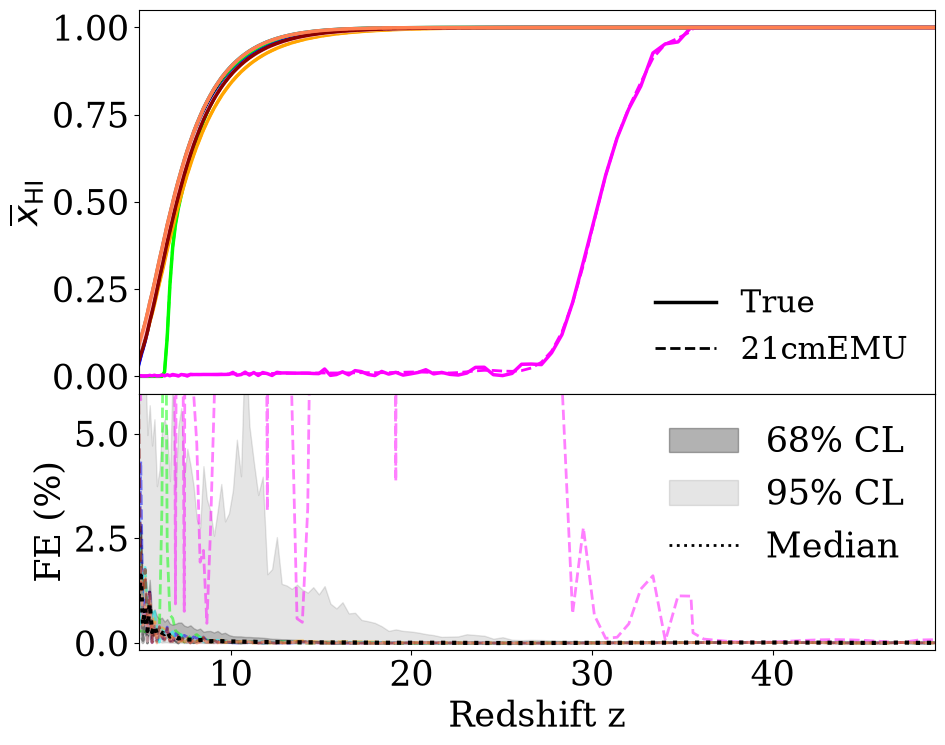

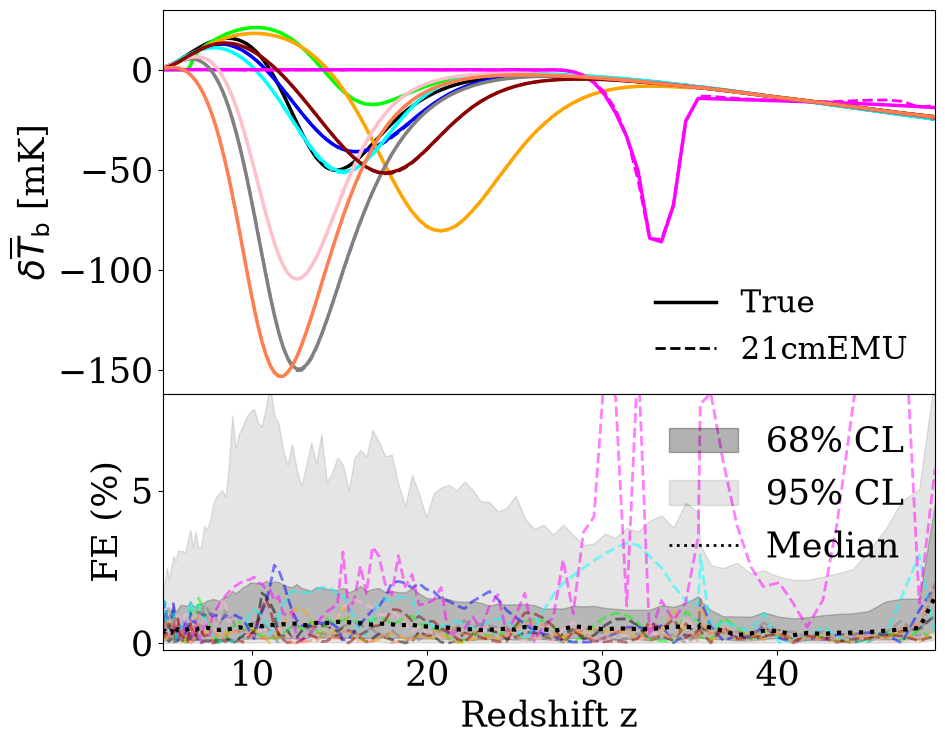

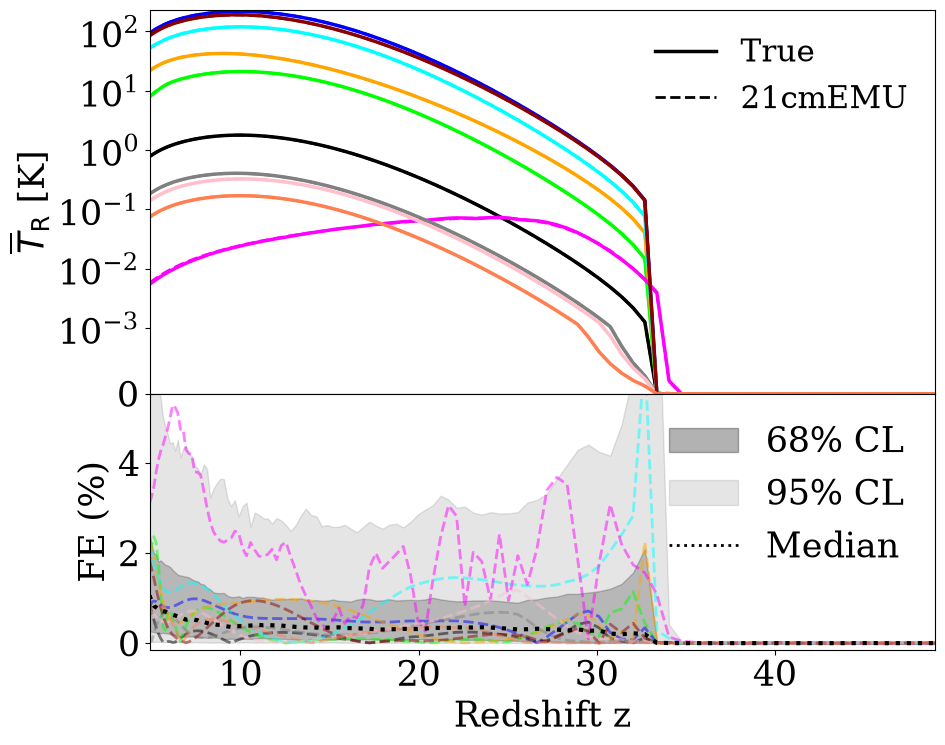

In [7]:
CS = ["k", "lime", "b", "orange", "cyan", "magenta", "grey", "pink", "darkred", "coral"]


def clean_symlog_ticks(ax, linthresh, max_ticks=8):
    # drop symlog ticks inside the linear region (except 0) and thin crowded decades
    lo, hi = ax.get_ylim()
    ticks = [t for t in ax.get_yticks() if lo <= t <= hi and (t == 0 or abs(t) >= linthresh)]
    nonzero = [t for t in ticks if t != 0]
    if len(nonzero) > max_ticks:
        keep = {t for t in nonzero if round(np.log10(abs(t))) % 2 == 0}
        ticks = [t for t in ticks if t == 0 or t in keep]
    ax.set_yticks(ticks)
    ax.set_ylim(lo, hi)


def plot_true_vs_emu(x, y_true, y_emu, y_fe, y_label, N=10, offset=0,
                     yscale=None, linthresh=1.0, ybottom=None):
    '''Top: N true (solid) and emulated (dashed) curves. Bottom: their FE and the
    median / 68% / 95% intervals of the FE over all samples.'''
    fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8),
                            gridspec_kw=dict(height_ratios=[3, 2], hspace=0))
    band = np.percentile(y_fe, [2.5, 16, 50, 84, 97.5], axis=0)
    for i, c in zip(range(offset, offset + N), CS, strict=False):
        axs[0].plot(x, y_true[i], lw=2.5, color=c)
        axs[0].plot(x, y_emu[i], lw=2, ls="--", color=c)
        axs[1].plot(x, y_fe[i], ls="--", alpha=0.5, lw=2, color=c)
    axs[1].plot(x, band[2], ls=":", lw=3, color="k")
    axs[1].fill_between(x, band[1], band[3], color="k", alpha=0.2)
    axs[1].fill_between(x, band[0], band[4], color="k", alpha=0.1)

    axs[0].legend(handles=[Line2D([0], [0], color="k", lw=2.5, label="True"),
                           Line2D([0], [0], color="k", lw=2, ls="--", label="21cmEMU")],
                  frameon=False, fontsize=22)
    axs[1].legend(handles=[mpatches.Patch(color="k", label="68% CL", alpha=0.3),
                           mpatches.Patch(color="k", label="95% CL", alpha=0.1),
                           Line2D([0], [0], color="k", lw=2, ls=":", label="Median")],
                  loc="upper right", frameon=False)
    if yscale == "symlog":
        axs[0].set_yscale("symlog", linthresh=linthresh)
    if ybottom is not None:
        axs[0].set_ylim(bottom=ybottom)
    if yscale == "symlog":
        clean_symlog_ticks(axs[0], linthresh)
    top = np.percentile(band[4], 90)  # robust to a few extreme redshifts
    axs[1].set_ylim(-0.03 * top, 1.15 * top)
    axs[0].set_ylabel(y_label)
    axs[1].set_ylabel("FE (%)")
    axs[1].set_xlabel("Redshift z")
    axs[1].set_xlim(x.min(), x.max())
    return fig


rcParams.update({"font.size": 25, "font.family": "serif"})
z = output.redshifts.value
tb_symlog = np.abs(true["Tb"][:N_PLOT]).max() > 1e3  # very deep absorption troughs
settings = {
    "xHI": dict(y_label=r"$\overline{x}_{\rm HI}$"),
    "Tb": dict(y_label=r"$\delta\overline{T}_{\rm b}$ [mK]",
               yscale="symlog" if tb_symlog else None, linthresh=5.0),
    "Tr": dict(y_label=r"$\overline{T}_{\rm R}$ [K]", yscale="symlog", linthresh=1e-3,
               ybottom=0),
}
for t, kw in settings.items():
    fig = plot_true_vs_emu(z, true[t], emulated[t], fe[t], N=N_PLOT, **kw)
    plt.tight_layout()
    plt.show()

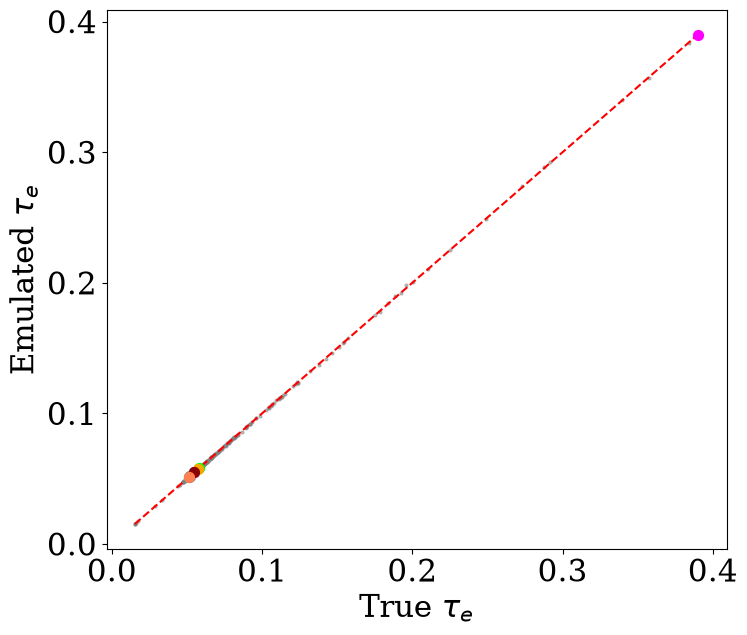

In [8]:
rcParams.update({"font.size": 22})
fig = plt.figure(figsize=(8, 7))
plt.scatter(true["tau"], emulated["tau"], s=4, color="grey", alpha=0.5)
for i, c in zip(range(N_PLOT), CS, strict=False):
    plt.scatter(true["tau"][i], emulated["tau"][i], color=c, s=50, zorder=3)
lim = [true["tau"].min(), true["tau"].max()]
plt.plot(lim, lim, "r--", lw=1.5)
plt.xlabel(r"True $\tau_e$")
plt.ylabel(r"Emulated $\tau_e$")
plt.show()

## With vs without radio heating

Both emulators take the same parameters, so the effect of radio heating on the global signal can be read off directly: radio heating warms the gas, which makes the absorption trough shallower in `rh` (solid) than in `norh` (dashed).

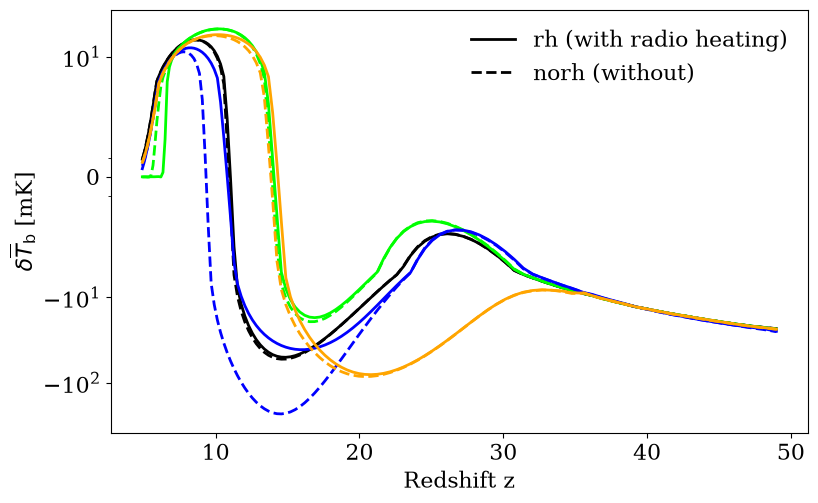

In [9]:
emus = {name: Emulator(emulator=name) for name in ("rh", "norh")}
theta_demo = params[:4]
out_demo = {name: e.predict(theta_demo)[1] for name, e in emus.items()}

rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, c in zip(range(len(theta_demo)), CS, strict=False):
    ax.plot(z, out_demo["rh"].Tb[i], color=c, lw=2)
    ax.plot(z, out_demo["norh"].Tb[i], color=c, lw=2, ls="--")
ax.set_yscale("symlog", linthresh=5.0)
clean_symlog_ticks(ax, 5.0)
ax.set_xlabel("Redshift z")
ax.set_ylabel(r"$\delta\overline{T}_{\rm b}$ [mK]")
ax.legend(handles=[Line2D([0], [0], color="k", lw=2, label="rh (with radio heating)"),
                   Line2D([0], [0], color="k", lw=2, ls="--", label="norh (without)")],
          frameon=False)
plt.show()